In [101]:
import pandas as pd
import xarray as xr
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

def get_filtered_filenames(folder_path):
    filenames = [
        f for f in os.listdir(folder_path)
        if f.endswith('.dat') and 'spectrum' in f and "SnV_" in f and os.path.isfile(os.path.join(folder_path, f))
    ]
    return filenames

def read_in_data(file_path):
    with open(file_path, 'r') as file:
        # read in metadata
        metadata = {}
        data_start_line = None
        for i, line in enumerate(file):
            if line.startswith("#"):
                # Extract key-value pairs from metadata
                if "=" in line:
                    key, value = line[2:].strip().split("=", 1)
                    metadata[key.strip()] = value.strip()
            else:
                data_start_line = i
                break
            
        data = pd.read_csv(file_path, sep='\t', skiprows=data_start_line, header=None)
        
        xrData = xr.Dataset(
                data_vars=dict(
                    intensity=xr.Variable('wavelength', data[1] , dict(units=r'au', long_name='Intensity')),             
                ),
                coords=dict(
                    wavelength=xr.Variable('wavelength', data[0]*1e-9, attrs=dict(units=r'nm', long_name='Wavelength')),
                    
                )
            )
    return xrData

# Lorentzian function
def lorentzian(x, x0, gamma, A):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

# Two Lorentzians
def double_lorentzian(x, x01, gamma1, A1, x02, gamma2, A2):
    return (lorentzian(x, x01, gamma1, A1) +
            lorentzian(x, x02, gamma2, A2))

# Gaussian function
def gaussian(x, x0, sigma, A):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Two Gaussians
def double_gaussian(x, x01, sigma1, A1, x02, sigma2, A2):
    return (gaussian(x, x01, sigma1, A1) +
            gaussian(x, x02, sigma2, A2))

def fit_data_with_peak_finding(x_data, y_data, model='lorentzian'):
    # Find peaks
    try:
        peaks, _ = find_peaks(y_data, height=np.max(y_data) * 0.1)  # Detect peaks above 10% of max height
        peak_indices = peaks[np.argsort(y_data[peaks])][-2:]  # Get indices of the two tallest peaks
        peak_indices = np.sort(peak_indices)  # Ensure order consistency
        
        x01_guess, x02_guess = x_data[peak_indices]
        y01_guess, y02_guess = y_data[peak_indices]
        
        if model == 'lorentzian':
            p0 = [x01_guess, 1, y01_guess,  # Initial guess for first Lorentzian
                x02_guess, 1, y02_guess]  # Initial guess for second Lorentzian
            popt, pcov = curve_fit(double_lorentzian, x_data, y_data, p0=p0)
        elif model == 'gaussian':
            p0 = [x01_guess, 1, y01_guess,  # Initial guess for first Gaussian
                x02_guess, 1, y02_guess]  # Initial guess for second Gaussian
            popt, pcov = curve_fit(double_gaussian, x_data, y_data, p0=p0)
        else:
            raise ValueError("Model must be 'lorentzian' or 'gaussian'.")
        
        return popt, pcov
    except BaseException as e:
        print("couldnt fit", end="")
        return None, None

def get_name(filename):
    match = re.search(r"spectrum_(.*?)\.dat", filename)
    if match:
        return match.group(1)
    return "error"

def wavelength_to_freq_diff(wavelength1, wavelength2):
    # Speed of light in m/s
    c = 3e8
    # Convert wavelengths from nm to meters
    lambda1_m = wavelength1 * 1e-9
    lambda2_m = wavelength2 * 1e-9
    # Calculate frequencies in Hz
    freq1 = c / lambda1_m
    freq2 = c / lambda2_m
    # Frequency difference in Hz
    freq_diff_hz = abs(freq1 - freq2)
    # Convert to GHz
    freq_diff_ghz = freq_diff_hz / 1e9
    
    return freq_diff_ghz

In [109]:
folder_path = r"\\pi3-file\transfer\QINU\05_Data\waveguides_spectrometer"

filepaths = get_filtered_filenames(folder_path)
data_dict = {}
not_fitted = []
for filepath in filepaths:
    xrData = read_in_data(f"{folder_path}\{filepath}")
    popt, pcov = fit_data_with_peak_finding(np.array(xrData.wavelength), np.array(xrData.intensity))
    if popt is not None:
        xrData.attrs["name"] = get_name(filepath)
        xrData.attrs["popt"] = popt
        xrData.attrs["distance_GHz"] = wavelength_to_freq_diff(popt[0], popt[3])
        data_dict[get_name(filepath)] = xrData
    else:
        not_fitted.append(get_name(filepath))

print(not_fitted)

couldnt fitcouldnt fit['SnV_8_3', 'SnV_36_3']


SnV_1_3 splitting: 1117 GhZ
SnV_2_3 splitting: 1165 GhZ
SnV_3_3 splitting: 1123 GhZ
SnV_4_3 splitting: 1118 GhZ
SnV_5_3 splitting: 148 GhZ
SnV_6_3 splitting: 1568 GhZ
SnV_7_3 splitting: 1091 GhZ
SnV_9_3 splitting: 1179 GhZ
SnV_10_3 splitting: 12494 GhZ
SnV_11_3 splitting: 1123 GhZ
SnV_12_3 splitting: 1725 GhZ
SnV_13_3 splitting: 1206 GhZ
SnV_14_3 splitting: 1071 GhZ
SnV_15_3 splitting: 1272 GhZ
SnV_16_3 splitting: 1133 GhZ
SnV_17_3 splitting: 1439 GhZ
SnV_18_3 splitting: 1136 GhZ
SnV_19_3 splitting: 714 GhZ
SnV_20_3 splitting: 1140 GhZ
SnV_21_3 splitting: 1115 GhZ
SnV_22_3 splitting: 1250 GhZ
SnV_23_3 splitting: 892 GhZ
SnV_24_3 splitting: 1118 GhZ
SnV_25_3 splitting: 1124 GhZ
SnV_26_3 splitting: 1142 GhZ
SnV_27_3 splitting: 1258 GhZ
SnV_28_3 splitting: 1122 GhZ
SnV_29_3 splitting: 1118 GhZ
SnV_30_3 splitting: 251 GhZ
SnV_31_3 splitting: 1133 GhZ
SnV_32_3 splitting: 1123 GhZ
SnV_33_3 splitting: 1245 GhZ
SnV_34_3 splitting: 1124 GhZ
SnV_35_3 splitting: 1115 GhZ
SnV_37_3 splitting: 665 G

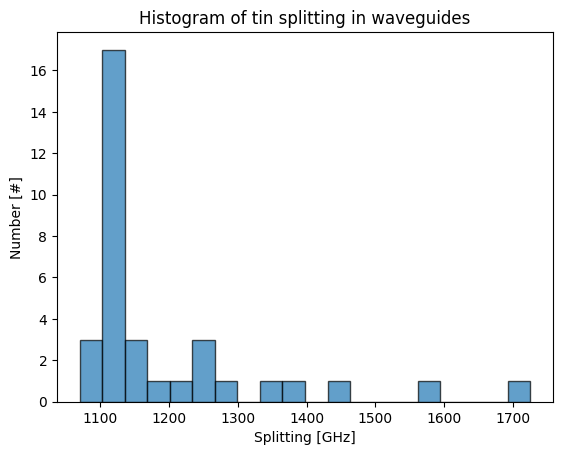

In [ ]:
splittings = []
for xrData in data_dict.values():
    print(f"{xrData.attrs['name']} splitting: {xrData.attrs['distance_GHz']:.0f} GhZ")
    splittings.append(xrData.attrs['distance_GHz'])
filtered_splittings = [x for x in splittings if 1000 <= x <= 2000]
plt.hist(filtered_splittings, bins=50, edgecolor='black', alpha=0.7)

# Add labels and title
plt.xlabel('Splitting [GHz]')
plt.ylabel('Number [#]')
plt.title('Histogram of tin splitting in waveguides')

# Show the plot
plt.show()


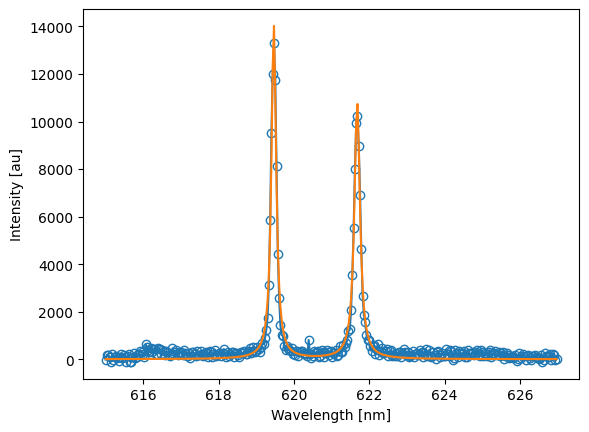

In [121]:
name = "SnV_12_3"
xrData_all = data_dict[name]
xrData = xrData_all.sel(wavelength=slice(615, 627))
xrData.intensity.plot(label="Data", marker='o', fillstyle='none', linestyle='-')
fit_data = double_lorentzian(xrData.wavelength, *xrData.attrs["popt"])
plt.plot(xrData.wavelength, fit_data, label='Fitted Data')

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Lorentzian function
def lorentzian(x, x0, gamma, A):
    return A * gamma**2 / ((x - x0)**2 + gamma**2)

# Two Lorentzians
def double_lorentzian(x, x01, gamma1, A1, x02, gamma2, A2):
    return (lorentzian(x, x01, gamma1, A1) +
            lorentzian(x, x02, gamma2, A2))

# Gaussian function
def gaussian(x, x0, sigma, A):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))

# Two Gaussians
def double_gaussian(x, x01, sigma1, A1, x02, sigma2, A2):
    return (gaussian(x, x01, sigma1, A1) +
            gaussian(x, x02, sigma2, A2))

def fit_data(x_data, y_data, model='lorentzian'):
    """
    Fits the data to the specified model.
    
    Parameters:
        x_data (array): The x values of the dataset.
        y_data (array): The y values of the dataset.
        model (str): Either 'lorentzian' or 'gaussian'.
    
    Returns:
        popt (array): Optimal parameters.
        pcov (array): Covariance of the fit.
    """
    try:
        if model == 'lorentzian':
            p0 = [x_data[np.argmax(y_data)], 1, max(y_data),  # Initial guess for first Lorentzian
                x_data[np.argmax(y_data)] + 1, 1, max(y_data) / 2]  # Initial guess for second Lorentzian
            popt, pcov = curve_fit(double_lorentzian, x_data, y_data, p0=p0)
            return popt, pcov
        elif model == 'gaussian':
            p0 = [x_data[np.argmax(y_data)], 1, max(y_data),  # Initial guess for first Gaussian
                x_data[np.argmax(y_data)] + 1, 1, max(y_data) / 2]  # Initial guess for second Gaussian
            popt, pcov = curve_fit(double_gaussian, x_data, y_data, p0=p0)
            return popt, pcov
        else:
            raise ValueError("Model must be 'lorentzian' or 'gaussian'.")
    except BaseException as e:
        print("could not fit")
        return p0, None
        